# Tidy Data - Melt and Pivot

COMP 6934 \
Karteek Popuri

This notebook looks at the concept of tidy data. Tidy data is data where:
- Every column is a variable.
- Every row is an observation.
- Every cell is a single value.

Our objectives in this notebook are to learn about:
- pandas methods to transform how data is arranged in a DataFrame

API for melt:
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.melt.html

API for pivot:
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html

## Load Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

We will work with the superhero movie data set that was used in the slides for this lecture.

In [2]:
df = pd.read_csv('marvel-dc-movies.csv')

In [3]:
df

,Original Title,Company,Rating,Gross Worldwide
0,Guardians of the Galaxy Vol. 2,Marvel,7.6,863756051
1,Spider-Man: Homecoming,Marvel,7.4,880166924
2,Thor:Ragnarok,Marvel,7.9,853977126
3,Black Panther,Marvel,7.3,1346913161
4,Avengers: Infinity War,Marvel,8.5,2048359754
5,Ant-Man and the Wasp,Marvel,7.1,622674139
6,Captain Marve,Marvel,6.9,1128274794
7,Avengers: Endgame,Marvel,8.5,2797800564
8,Spider-Man: Far from Home,Marvel,7.6,1131927996
9,Wonder Woman,DC,7.4,821847012


Each row is a movie. It contains the name of the movie, the cinematic universe to which it belongs, its rating and its worldwide gross in sales.

## Melt

pandas ``.melt()`` is a way to convert column data into key-value pairs. 

It takes two arguments. The first is a list of columns that act as the identifier variables. The second is a list of columns that are to be converted into key-value pairs.

Using ``.melt()``, we shall convert the rating and the worldwide gross for each movie into key-value pairs.

In [4]:
df.melt(id_vars=['Gross Worldwide'], value_vars=['Original Title', 'Company', 'Rating'])

,Gross Worldwide,variable,value
0,863756051,Original Title,Guardians of the Galaxy Vol. 2
1,880166924,Original Title,Spider-Man: Homecoming
2,853977126,Original Title,Thor:Ragnarok
3,1346913161,Original Title,Black Panther
4,2048359754,Original Title,Avengers: Infinity War
5,622674139,Original Title,Ant-Man and the Wasp
6,1128274794,Original Title,Captain Marve
7,2797800564,Original Title,Avengers: Endgame
8,1131927996,Original Title,Spider-Man: Far from Home
9,821847012,Original Title,Wonder Woman


Notice that the ``Rating`` and ``Worldwide Gross`` columns have been replaced with ``variable`` (key) and ``value`` columns. 

All of the same data is present in our DataFrame. It is just arranged differently.

We could also include Company as one of the key-value pairs. Now we have 3 key-value pairs in the variable / value columns.

In [5]:
df2 = df.melt(id_vars=['Original Title'], value_vars=['Company', 'Rating', 'Gross Worldwide']).sort_values(by='Original Title')

In [6]:
df2[df2.variable == 'Gross Worldwide'].value

33     622674139
39    1148161807
35    2797800564
32    2048359754
31    1346913161
34    1128274794
28     863756051
41    1060504580
38     657924295
40     364571656
36    1131927996
29     880166924
30     853977126
37     821847012
Name: value, dtype: object

What would we use as the x- and y-data if we wanted to make a scatter plot of rating vs worldwide gross and our data was in this format?
 
The values for rating and worldwide gross of each movie are contained in the same column. That will make it hard to plot this data in this form.

We can plot it easily with our original DataFrame because the x/y data are in separate columns. This is not true for our untidy DataFrame.



In [7]:
df

,Original Title,Company,Rating,Gross Worldwide
0,Guardians of the Galaxy Vol. 2,Marvel,7.6,863756051
1,Spider-Man: Homecoming,Marvel,7.4,880166924
2,Thor:Ragnarok,Marvel,7.9,853977126
3,Black Panther,Marvel,7.3,1346913161
4,Avengers: Infinity War,Marvel,8.5,2048359754
5,Ant-Man and the Wasp,Marvel,7.1,622674139
6,Captain Marve,Marvel,6.9,1128274794
7,Avengers: Endgame,Marvel,8.5,2797800564
8,Spider-Man: Far from Home,Marvel,7.6,1131927996
9,Wonder Woman,DC,7.4,821847012


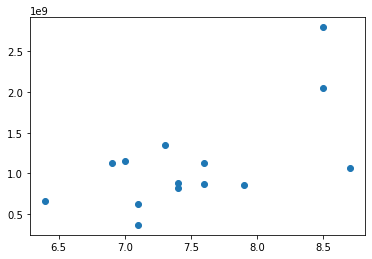

In [8]:
fig, ax = plt.subplots()

ax.scatter(df['Rating'], df['Gross Worldwide'])

## Pivot (Un-melt)

To un-melt a DataFrame, we can use ``.pivot()``.

It takes three arguments:
- The first is a list of identifier variables - these are the same identifier variables you used when melting. 
- The second is the column that contains the key names. 
- The third is the value. (Making the second and third columns the key/value pairs.)

In [9]:
df_melt = df.melt(id_vars=['Original Title'], value_vars=['Company', 'Rating', 'Gross Worldwide'])

In [10]:
df_melt

,Original Title,variable,value
0,Guardians of the Galaxy Vol. 2,Company,Marvel
1,Spider-Man: Homecoming,Company,Marvel
2,Thor:Ragnarok,Company,Marvel
3,Black Panther,Company,Marvel
4,Avengers: Infinity War,Company,Marvel
5,Ant-Man and the Wasp,Company,Marvel
6,Captain Marve,Company,Marvel
7,Avengers: Endgame,Company,Marvel
8,Spider-Man: Far from Home,Company,Marvel
9,Wonder Woman,Company,DC


We can un-melt our DataFrame using `.pivot()`.

In [11]:
df_melt.pivot(index=['Original Title'], columns='variable', values='value').reset_index()

variable,Original Title,Company,Gross Worldwide,Rating
0,Ant-Man and the Wasp,Marvel,622674139,7.1
1,Aquaman,DC,1148161807,7.0
2,Avengers: Endgame,Marvel,2797800564,8.5
3,Avengers: Infinity War,Marvel,2048359754,8.5
4,Black Panther,Marvel,1346913161,7.3
5,Captain Marve,Marvel,1128274794,6.9
6,Guardians of the Galaxy Vol. 2,Marvel,863756051,7.6
7,Joker,DC,1060504580,8.7
8,Justice League,DC,657924295,6.4
9,Shazam!,DC,364571656,7.1


And just like that, we have un-melted our DataFrame.

Keep in mind that ``.pivot()`` will set the index of the resulting DataFrame to the identifier variables. Just like with ``.groupby()``, applying a ``.reset_index()`` will change those back to regular columns.

## Dangerous Melts

Sometimes melting data can cause information loss. In the previous example, the movie name uniquely identifies an observation. If we melt using the company column, what happens?

In [12]:
df

,Original Title,Company,Rating,Gross Worldwide
0,Guardians of the Galaxy Vol. 2,Marvel,7.6,863756051
1,Spider-Man: Homecoming,Marvel,7.4,880166924
2,Thor:Ragnarok,Marvel,7.9,853977126
3,Black Panther,Marvel,7.3,1346913161
4,Avengers: Infinity War,Marvel,8.5,2048359754
5,Ant-Man and the Wasp,Marvel,7.1,622674139
6,Captain Marve,Marvel,6.9,1128274794
7,Avengers: Endgame,Marvel,8.5,2797800564
8,Spider-Man: Far from Home,Marvel,7.6,1131927996
9,Wonder Woman,DC,7.4,821847012


Each row has a unique movie title. This allows it to act as a unique index when we melt.

In [13]:
df.melt(id_vars=['Company'], value_vars=['Original Title', 'Rating', 'Gross Worldwide'])

,Company,variable,value
0,Marvel,Original Title,Guardians of the Galaxy Vol. 2
1,Marvel,Original Title,Spider-Man: Homecoming
2,Marvel,Original Title,Thor:Ragnarok
3,Marvel,Original Title,Black Panther
4,Marvel,Original Title,Avengers: Infinity War
5,Marvel,Original Title,Ant-Man and the Wasp
6,Marvel,Original Title,Captain Marve
7,Marvel,Original Title,Avengers: Endgame
8,Marvel,Original Title,Spider-Man: Far from Home
9,DC,Original Title,Wonder Woman


For any particular movie, we can find the company the produced the movie, its rating, and its gross worldwide sales. The movie title is unique, so this works ok.

However, the Company is not a unique identifier. Multiple movies have the same Company. If we melt using Company, we will lose information.

In [14]:
df_melt = df.melt(id_vars=['Company'], value_vars=['Original Title', 'Rating', 'Gross Worldwide'])

In [15]:
df_melt.pivot(index='Company', columns='variable', values='value')

ValueError: Index contains duplicate entries, cannot reshape

In the above, we cannot determine the Gross Worldwide of Rating of any specific movie. For example, there is a movie with a rating of 8.7 -- but which movie is it? All the values are still present, but we no longer know how to associate the values together.

We cannot use ``.pivot()`` to un-melt our data. Using only whether the movie was made by Marvel or DC does not uniquely identify it -- they create many movies. 

## Summary

``melt()`` and ``pivot()`` are useful for managing the shape of your data. If you have a data set that is not in a tidy format, then these may help re-arrange your data to make it tidy.

They may also be useful for re-arranging your data to match the API of another library you are working with.